Training SAC agent with reward shaping...


  5%|▌         | 10/200 [02:05<39:45, 12.56s/it]

Episode: 10, Reward: -23.34, Avg Reward: -29.71


 10%|█         | 20/200 [04:11<37:44, 12.58s/it]

Episode: 20, Reward: -2.81, Avg Reward: -0.52


 15%|█▌        | 30/200 [06:11<33:59, 12.00s/it]

Episode: 30, Reward: -0.59, Avg Reward: -1.13


 18%|█▊        | 35/200 [06:57<32:46, 11.92s/it]

Environment solved in 36 episodes!


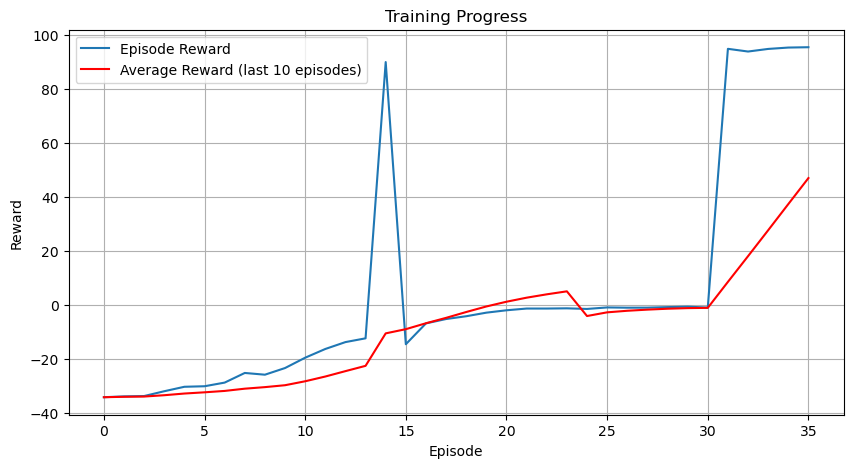


Evaluating agent...
Mean reward: 67.05, Std reward: 44.20

Rendering a single episode...


In [1]:
import gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal
import random
from collections import deque
import matplotlib.pyplot as plt
from tqdm import tqdm

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import warnings
warnings.filterwarnings("ignore")

# 設定隨機種子以確保可重現性
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256, log_std_min=-20, log_std_max=2):
        super(Actor, self).__init__()
        self.log_std_min = log_std_min
        self.log_std_max = log_std_max
        
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        
        self.mu = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Linear(hidden_dim, action_dim)

    def forward(self, state):
        x = self.net(state)
        mu = self.mu(x)
        log_std = self.log_std(x)
        log_std = torch.clamp(log_std, self.log_std_min, self.log_std_max)
        return mu, log_std

    def sample(self, state):
        mu, log_std = self.forward(state)
        std = log_std.exp()
        
        normal = Normal(mu, std)
        x_t = normal.rsample()  # 重參數化技巧
        
        action = torch.tanh(x_t)
        
        # 計算log_prob，考慮tanh轉換
        log_prob = normal.log_prob(x_t) - torch.log(1 - action.pow(2) + 1e-6)
        log_prob = log_prob.sum(1, keepdim=True)
        
        return action, log_prob, torch.tanh(mu)

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super(Critic, self).__init__()
        
        # Q1
        self.q1_net = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        
        # Q2
        self.q2_net = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state, action):
        x = torch.cat([state, action], 1)
        q1 = self.q1_net(x)
        q2 = self.q2_net(x)
        return q1, q2

    def q1_forward(self, state, action):
        x = torch.cat([state, action], 1)
        return self.q1_net(x)

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done
    
    def __len__(self):
        return len(self.buffer)

def shape_reward(state, action, reward, done):
    position = state[0]
    velocity = state[1]
    
    # 位置獎勵 - 鼓勵接近目標
    position_reward = 0.1 * (position + 1.2) / 1.8
    
    # 速度獎勵 - 鼓勵有效速度
    velocity_reward = 0.1 * np.abs(velocity) if velocity > 0 else -0.05 * np.abs(velocity)
    
    # 高度獎勵 - 鼓勵爬升
    height = np.sin(3 * position) * 0.45 + 0.55
    height_reward = 0.1 * height
    
    # 能量懲罰
    energy_penalty = -0.1 * np.square(action[0])
    
    # 原始獎勵（達到目標）
    goal_reward = reward if done and position >= 0.5 else 0
    
    return position_reward + velocity_reward + height_reward + energy_penalty + goal_reward

class SAC:
    def __init__(self, state_dim, action_dim, lr=3e-4, gamma=0.99, tau=0.005):
        self.actor = Actor(state_dim, action_dim).to(device)
        self.critic = Critic(state_dim, action_dim).to(device)
        self.critic_target = Critic(state_dim, action_dim).to(device)
        
        # 複製參數
        for target_param, param in zip(self.critic_target.parameters(), self.critic.parameters()):
            target_param.data.copy_(param.data)
        
        # 優化器
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr)
        
        # 熵系數
        self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
        self.alpha_optimizer = optim.Adam([self.log_alpha], lr=lr)
        
        self.target_entropy = -action_dim
        self.gamma = gamma
        self.tau = tau
    
    def select_action(self, state, evaluate=False):
        state = torch.FloatTensor(state).to(device).unsqueeze(0)
        
        if evaluate:
            _, _, action = self.actor.sample(state)
        else:
            action, _, _ = self.actor.sample(state)
        
        return action.detach().cpu().numpy()[0]
    
    def update_parameters(self, memory, batch_size):
        # 採樣
        state_batch, action_batch, reward_batch, next_state_batch, done_batch = memory.sample(batch_size)
        
        # 轉換為Tensor
        state_batch = torch.FloatTensor(state_batch).to(device)
        action_batch = torch.FloatTensor(action_batch).to(device)
        reward_batch = torch.FloatTensor(reward_batch).to(device).unsqueeze(1)
        next_state_batch = torch.FloatTensor(next_state_batch).to(device)
        done_batch = torch.FloatTensor(done_batch).to(device).unsqueeze(1)
        
        alpha = self.log_alpha.exp()
        
        # 更新Critic
        with torch.no_grad():
            next_action, next_log_prob, _ = self.actor.sample(next_state_batch)
            next_q1, next_q2 = self.critic_target(next_state_batch, next_action)
            next_q = torch.min(next_q1, next_q2) - alpha * next_log_prob
            target_q = reward_batch + (1 - done_batch) * self.gamma * next_q
        
        current_q1, current_q2 = self.critic(state_batch, action_batch)
        critic_loss = F.mse_loss(current_q1, target_q) + F.mse_loss(current_q2, target_q)
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        
        # 更新Actor
        actions_new, log_prob, _ = self.actor.sample(state_batch)
        q1, q2 = self.critic(state_batch, actions_new)
        min_q = torch.min(q1, q2)
        
        actor_loss = (alpha * log_prob - min_q).mean()
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        
        # 更新alpha（熵溫度係數）
        alpha_loss = -(self.log_alpha * (log_prob + self.target_entropy).detach()).mean()
        
        self.alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.alpha_optimizer.step()
        
        # 軟更新目標網絡
        for target_param, param in zip(self.critic_target.parameters(), self.critic.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - self.tau) + param.data * self.tau)
        
        return critic_loss.item(), actor_loss.item()

def train(env_name="MountainCarContinuous-v0", max_episodes=200, batch_size=256, buffer_capacity=100000):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    
    agent = SAC(state_dim, action_dim)
    memory = ReplayBuffer(buffer_capacity)
    
    rewards = []
    avg_rewards = []
    
    for episode in tqdm(range(max_episodes)):
        state, _ = env.reset()
        episode_reward = 0
        done = False
        
        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # 使用Reward Shaping
            shaped_reward = shape_reward(state, action, reward, done)
            
            memory.push(state, action, shaped_reward, next_state, float(done))
            state = next_state
            episode_reward += reward  # 注意這裡使用原始reward來計算總回報
            
            if len(memory) > batch_size:
                agent.update_parameters(memory, batch_size)
        
        rewards.append(episode_reward)
        avg_reward = np.mean(rewards[-10:])
        avg_rewards.append(avg_reward)
        
        if (episode + 1) % 10 == 0:
            print(f'Episode: {episode+1}, Reward: {episode_reward:.2f}, Avg Reward: {avg_reward:.2f}')
        
        # 如果我們連續5次達到平均獎勵90以上，提前結束訓練
        if len(rewards) >= 5 and np.mean(rewards[-5:]) >= 90:
            print(f"Environment solved in {episode+1} episodes!")
            break
    
    return agent, rewards, avg_rewards

def evaluate(env_name, agent, num_episodes=10, render=False):
    env = gym.make(env_name, render_mode='human' if render else None)
    rewards = []
    
    for _ in range(num_episodes):
        state, _ = env.reset()
        episode_reward = 0
        done = False
        
        while not done:
            action = agent.select_action(state, evaluate=True)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            state = next_state
            episode_reward += reward
            
            if render:
                env.render()
        
        rewards.append(episode_reward)
    
    env.close()
    return np.mean(rewards), np.std(rewards)

def plot_rewards(rewards, avg_rewards, window_size=10):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, label='Episode Reward')
    plt.plot(avg_rewards, label=f'Average Reward (last {window_size} episodes)', color='red')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title('Training Progress')
    plt.legend()
    plt.grid()
    plt.savefig('sac_mountain_car_rewards.png')
    plt.show()

def main():
    env_name = "MountainCarContinuous-v0"
    
    print("Training SAC agent with reward shaping...")
    agent, rewards, avg_rewards = train(env_name)
    
    # 儲存模型
    torch.save(agent.actor.state_dict(), 'sac_actor.pth')
    torch.save(agent.critic.state_dict(), 'sac_critic.pth')
    
    # 視覺化訓練過程
    plot_rewards(rewards, avg_rewards)
    
    # 評估模型
    print("\nEvaluating agent...")
    mean_reward, std_reward = evaluate(env_name, agent, num_episodes=10)
    print(f"Mean reward: {mean_reward:.2f}, Std reward: {std_reward:.2f}")
    
    # 渲染一個episode
    print("\nRendering a single episode...")
    evaluate(env_name, agent, num_episodes=1, render=True)
    return agent

if __name__ == "__main__":
    agent = main()


In [2]:
def record_gif(env_name, agent, output_path="result.gif", num_episodes=1, fps=30):
    import imageio
    """
    記錄agent與環境互動的GIF檔案
    
    參數:
        env_name (str): 環境名稱
        agent: 訓練好的智能體
        output_path (str): 輸出GIF檔案的路徑
        num_episodes (int): 要記錄的episode數量
        fps (int): GIF的幀率
    """
    env = gym.make(env_name, render_mode="rgb_array")
    frames = []
    
    for episode in range(num_episodes):
        state, _ = env.reset()
        done = False
        step = 0
        episode_reward = 0
        
        while not done:
            # 選擇動作
            action = agent.select_action(state, evaluate=True)
            
            # 執行動作
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
            
            # 渲染並獲取畫面
            frame = env.render()
            frames.append(frame)
            
            # 添加文字資訊到畫面（如果需要的話）
            # （需要使用PIL或OpenCV）
            
            # 更新狀態
            state = next_state
            step += 1
        
        print(f"Episode {episode+1}: Steps = {step}, Reward = {episode_reward:.2f}")
    
    env.close()
    
    # 保存為GIF
    imageio.mimsave(output_path, frames, fps=fps)

In [4]:
record_gif("MountainCarContinuous-v0", agent, output_path="sac_mountain_car.gif", num_episodes=1, fps=30)

Episode 1: Steps = 261, Reward = 96.79
